#### Fig 6b

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import scanpy as sc  
#import squidpy as sq
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 500)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [5]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [6]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [7]:
adata_vis = adata_vis[adata_vis.obs['cond']!= "UNC"]

In [8]:
for i in range(4,20):
    mclust = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_{i}_no_UNC.csv")  # will just be one column
    adata_vis.obs[f'mclust_{i}'] = mclust.iloc[:, 0].values
    mclust_refined = pd.read_csv(f"/Users/jk/Documents/Lab2/visium/python_analysis/lambda/csv/mclust_refined_{i}_no_UNC.csv")  # will just be one column
    adata_vis.obs[f'mclust_refined_{i}'] = mclust_refined.iloc[:, 0].values

In [9]:
for col in adata_vis.obs.columns:
    if col.startswith("mclust"):
        adata_vis.obs[col] = adata_vis.obs[col].astype("category")

In [10]:
for i in range(4,20):
    mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
    df = adata_vis[(adata_vis.obs['cond']!="UNC") &    
                    (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
    counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
    # Step 2: Compute proportions per library_id
    total_counts = counts.groupby(['library_id'])['count'].transform('sum')
    counts['proportion'] = counts['count'] / total_counts

    # Step 3: Pivot to get factor_assigned proportions per library_id
    pivot_df = counts.pivot_table(
        index='library_id',
        columns=f'mclust_refined_{i}',
        values='proportion',
        fill_value=0
    )   
    pivot_df.to_csv(f"csv/prop_no_unc_mclust_refined_{i}.csv")


In [11]:
pivot_df.shape

(28, 19)

In [12]:
colors =     ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

In [13]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [14]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_57231_A3': 'CHP #1',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP #7',
 '17_25789_B1': 'CHP #8',
 '08_38774_B2': 'CHP #9',
 '16_39724_B1': 'CHP #10',
 '21_24095_A3': 'IPF #8',
 '21_55747_C3': 'IPF #9',
 '22_16220_B1': 'IPF #10'}

In [15]:
# i = 6
# mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
# df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
# # Create a blank dataframe
# counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
# # Step 2: Compute proportions per library_id
# total_counts = counts.groupby(['library_id'])['count'].transform('sum')
# counts['proportion'] = counts['count'] / total_counts

# # Step 3: Pivot to get factor_assigned proportions per library_id
# pivot_df = counts.pivot_table(
#     index='library_id',
#     columns=f'mclust_refined_{i}',
#     values='proportion',
#     fill_value=0
# )
# # Re-order columns
# pivot_df = pivot_df[list(range(i))]
# cond_order = df[['library_id', 'cond']].drop_duplicates().set_index('library_id').sort_index()
# pivot_df['cond'] = cond_order['cond']

# pivot_df['cond']  = pd.Categorical(pivot_df['cond'], categories=["IPF","NSIP",'CHP'], ordered=True)
# pivot_df.sort_values("cond")
# conditions = ["IPF","NSIP","CHP"]

# import matplotlib.gridspec as gridspec

# # Custom width ratios (adjust as needed — one per condition)
# widths = [
#     pivot_df[pivot_df['cond'] == conditions[0]].shape[0] * 0.15,
#     pivot_df[pivot_df['cond'] == conditions[1]].shape[0] * 0.15,
#     pivot_df[pivot_df['cond'] == conditions[2]].shape[0] * 0.15
# ]

# fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
# gs = gridspec.GridSpec(1, len(conditions), width_ratios=widths)

# axes = [fig.add_subplot(gs[i]) for i in range(len(conditions))]



# # Step 3: Set up subplots
# #fig, axes = plt.subplots(1, len(conditions), figsize=(3 * len(conditions), 5), sharey=True)

# # Custom color palette
# color_dict = dict(zip(
# range(i+1), colors[:i]


# ))

# # Step 4: Plot each condition
# for ax, cond in zip(axes, conditions):
#     subset = pivot_df[pivot_df['cond'] == cond].drop(columns='cond')
#     subset.plot(kind='bar', stacked=True, ax=ax,
#                 color=color_dict, 
#                 edgecolor='black')
#     ax.set_title(f'{cond}', fontsize = 14, pad = 5)
#     ax.set_xlabel('Sample')
#     ax.set_ylabel('Proportion of spots')
#     ax.legend(
#     title="Spatial niche",
#     loc='center left',
#     bbox_to_anchor=(1.05, 0.5),  # pushes legend outside to the right
#     frameon=False
# )

# for i in range(2):
#     axes[i].get_legend().remove()

# for ax in axes:
#     ax.set_xlabel("")

# for ax in axes[1:]:
#     ax.tick_params(labelleft=False)
#     ax.set_ylabel("")


# fig.text(0.4, -0.02, "Sample", fontsize = 14)

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_no_unc_individual_by_cond.pdf"), bbox_inches = 'tight', transparent = True)
# plt.show()

# # Extract handles and labels
# handles, labels = ax.get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=len(labels))  # ncol=2 for horizontal spread

# fig_legend.tight_layout()
# fig_legend.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_no_unc_individual_by_cond_legend.pdf"), bbox_inches = 'tight', transparent = True)
# fig_legend.show()





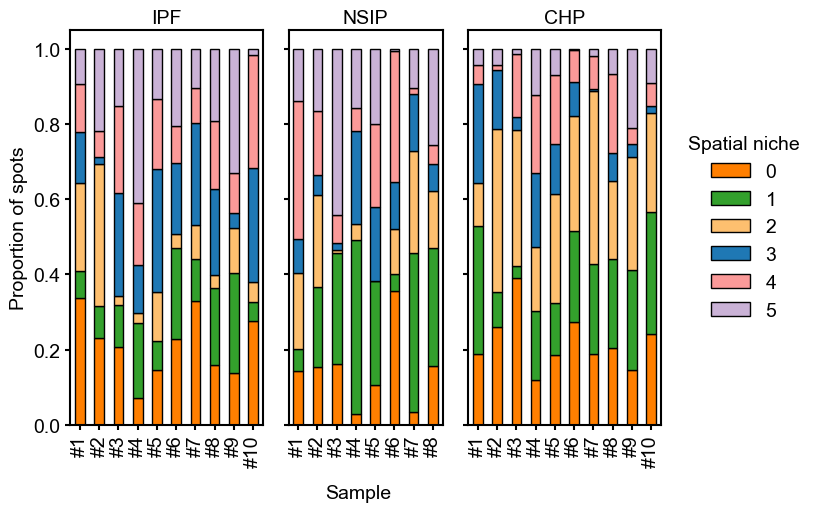

<Figure size 400x200 with 0 Axes>

In [16]:
i = 6
mclust = np.unique(adata_vis.obs[f'mclust_refined_{i}'])
df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs[f'mclust_refined_{i}'].isin(mclust))].obs[['library_id','cond','lobe_lr','sex', 'probe_lot', "lobe",'outcome_long','outcome_24m', f'mclust_refined_{i}']]
# Create a blank dataframe
counts = df.groupby(['library_id', f'mclust_refined_{i}']).size().reset_index(name='count')
# Step 2: Compute proportions per library_id
total_counts = counts.groupby(['library_id'])['count'].transform('sum')
counts['proportion'] = counts['count'] / total_counts

# Step 3: Pivot to get factor_assigned proportions per library_id
pivot_df = counts.pivot_table(
    index='library_id',
    columns=f'mclust_refined_{i}',
    values='proportion',
    fill_value=0
)
# Re-order columns
pivot_df = pivot_df[list(range(i))]
cond_order = df[['library_id', 'cond']].drop_duplicates().set_index('library_id').sort_index()
pivot_df['cond'] = cond_order['cond']

pivot_df['cond']  = pd.Categorical(pivot_df['cond'], categories=["IPF","NSIP",'CHP'], ordered=True)
pivot_df.sort_values("cond")
conditions = ["IPF","NSIP","CHP"]

import matplotlib.gridspec as gridspec

# Custom width ratios (adjust as needed — one per condition)
widths = [
    pivot_df[pivot_df['cond'] == conditions[0]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[1]].shape[0] * 0.15,
    pivot_df[pivot_df['cond'] == conditions[2]].shape[0] * 0.15
]

fig = plt.figure(figsize=(sum(widths) * 2, 5))  # overall figure size
gs = gridspec.GridSpec(1, len(conditions), width_ratios=widths)

axes = [fig.add_subplot(gs[i]) for i in range(len(conditions))]



# Step 3: Set up subplots
#fig, axes = plt.subplots(1, len(conditions), figsize=(3 * len(conditions), 5), sharey=True)

# Custom color palette
color_dict = dict(zip(
range(i+1), colors[:i]


))

# Step 4: Plot each condition
for ax, cond in zip(axes, conditions):
    # Without lay_id
    #subset = pivot_df[pivot_df['cond'] == cond].drop(columns='cond')

    ## With lay_id
    subset = (pivot_df[pivot_df['cond'] == cond]
        .drop(columns='cond')
        .rename(index = key_map) # .rename() updates library_id with lay_id
        .sort_index(
            key=lambda idx: [int(label.split('#')[1]) for label in idx.astype(str)])
            ) # sorts it naturally from 1 to 10

    # Strip everything before #
    subset.index = "#" + subset.index.astype(str).str.split("#").str[1]
    ##
    subset.plot(kind='bar', stacked=True, ax=ax,
                color=color_dict, 
                edgecolor='black')
    ax.set_title(f'{cond}', fontsize = 14, pad = 5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Proportion of spots')
    ax.legend(
    title="Spatial niche",
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),  # pushes legend outside to the right
    frameon=False
)

for i in range(2):
    axes[i].get_legend().remove()

for ax in axes:
    ax.set_xlabel("")

for ax in axes[1:]:
    ax.tick_params(labelleft=False)
    ax.set_ylabel("")


fig.text(0.4, -0.02, "Sample", fontsize = 14)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_individual_by_cond.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Spatial niche", loc='right', frameon=False, bbox_to_anchor=(1.1, 0.5), ncol=len(labels))  # ncol=2 for horizontal spread

fig_legend.tight_layout()
fig_legend.savefig(os.path.join(save_dir, "stacked_bar_mclust_refined_6_individual_by_cond_legend.pdf"), bbox_inches = 'tight', transparent = True)
fig_legend.show()



